# Model Calibration

**Notebook 5 of 5** in the AURA training pipeline.

The MLP trained in `04.model_training.ipynb` produces raw softmax outputs, not calibrated probabilities. A score of 0.92 is a high activation value — it is not a claim that the model is 92% confident. Every downstream decision in the inference module (block outright, flag for review, pass through) will be made against these numbers, so if they are not calibrated, the thresholds we choose are arbitrary guesses rather than meaningful confidence levels.

This notebook fits a post-hoc calibrator on top of the trained MLP. The calibrator is a small, lightweight function that learns the mapping from raw MLP scores to true observed probabilities. It is fit on the validation partition — a block of ~15% of the original dataset that was held out from MLP training entirely (see `04.model_training.ipynb`, split cells near the top). The isolation matters: if the calibrator saw the same rows the MLP was trained on, the model's memorisation would mask its real miscalibration.

Four calibration approaches are trained and compared: isotonic regression, beta calibration, Platt (sigmoid) scaling, and histogram binning. All four are evaluated on the same held-out validation set using Expected Calibration Error (primary), Brier score (secondary), and a reliability diagram (visual check). The winner is saved as `models/pipeline_components/calibrator.pkl` and the per-version `model_metadata.json` is updated with a `calibration` block.

In [1]:
# Imports and paths.
# Library choices:
# - sklearn: IsotonicRegression, CalibratedClassifierCV (Platt), metrics
# - betacal: BetaCalibration (pip install betacal)
# - netcal: HistogramBinning  (pip install netcal)
# - joblib: artifact serialisation, matching the rest of the pipeline

import json
import os
from datetime import datetime, timezone

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

# sklearn >= 1.6 removed cv='prefit' in favour of wrapping the fitted estimator
# with FrozenEstimator. The semantics are identical — the MLP is treated as fixed
# and only the sigmoid calibration head is fit on top.
from sklearn.frozen import FrozenEstimator

from betacal import BetaCalibration
from netcal.binning import HistogramBinning

MODEL_PATH = "models/v1_0/production/phishing_detector_mlp_classifier.pkl"
METADATA_PATH = "models/v1_0/production/model_metadata.json"
X_VAL_PATH = "datasets/calibration/X_val.npy"
Y_VAL_PATH = "datasets/calibration/y_val.npy"
CALIBRATOR_OUT = "models/pipeline_components/calibrator.pkl"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load the MLP and validation set

The MLP is loaded from disk and treated as fixed — no retraining, no `partial_fit`. The validation set (`X_val`, `y_val`) was saved by `04.model_training.ipynb` and was held out from MLP training entirely, which is exactly the condition a calibrator needs to observe honest (un-memorised) model behaviour.

In [2]:
mlp = joblib.load(MODEL_PATH)
X_val = np.load(X_VAL_PATH)
y_val = np.load(Y_VAL_PATH)

assert X_val.shape[1] == mlp.n_features_in_, (
    f"Validation features ({X_val.shape[1]}) do not match MLP input ({mlp.n_features_in_})"
)

print(f"MLP loaded:        hidden_layers={mlp.hidden_layer_sizes}, n_features_in={mlp.n_features_in_}")
print(f"X_val shape:       {X_val.shape}")
print(f"y_val shape:       {y_val.shape}")
print(f"Class distribution: phishing={int((y_val == 1).sum())}, legitimate={int((y_val == 0).sum())}")

MLP loaded:        hidden_layers=(256, 128, 64), n_features_in=7015
X_val shape:       (14868, 7015)
y_val shape:       (14868,)
Class distribution: phishing=8460, legitimate=6408


In [3]:
# Fit/eval split inside the calibration set.
#
# Fitting every calibrator on all 14 868 validation rows and then reporting
# ECE/Brier on the same rows makes isotonic and histogram binning look perfect
# (ECE ≈ 0) simply because both memorise the empirical calibration curve on
# the rows they were fit on. That in-sample tautology is what made the saved
# isotonic stair-step look like the best choice even though it collapses
# ~4-point-wide raw bands to a single output.
#
# Stratified 70/30: calibrators fit on the 70% fit fold, all metrics and the
# reliability diagram in the following sections are computed on the untouched
# 30% eval fold. Class proportions are preserved so neither fold drifts from
# the overall 8460/6408 phishing/legitimate split.
from sklearn.model_selection import train_test_split

X_fit, X_eval, y_fit, y_eval = train_test_split(
    X_val, y_val, test_size=0.3, stratify=y_val, random_state=RANDOM_STATE
)
print(f"fit fold : X={X_fit.shape}, phishing={int((y_fit == 1).sum())}, legitimate={int((y_fit == 0).sum())}")
print(f"eval fold: X={X_eval.shape}, phishing={int((y_eval == 1).sum())}, legitimate={int((y_eval == 0).sum())}")

fit fold : X=(10407, 7015), phishing=5922, legitimate=4485
eval fold: X=(4461, 7015), phishing=2538, legitimate=1923


## 2. Uncalibrated baseline

Compute the raw MLP probabilities for the positive class (phishing) on the validation set. These are the numbers the calibrators will correct. They are also the reference line in the reliability diagram — a perfectly calibrated model would track the diagonal; any deviation is miscalibration the calibrator is trying to fix.

In [4]:
# predict_proba returns shape (N, 2) with columns [legitimate, phishing]; we keep col 1.
# Raw probs on both folds: fit-fold probs train each calibrator; eval-fold probs
# feed the out-of-sample metrics in §5 and the reliability diagram in §6.
raw_probs_fit = mlp.predict_proba(X_fit)[:, 1]
raw_probs_eval = mlp.predict_proba(X_eval)[:, 1]
print(f"raw_probs_fit:  shape={raw_probs_fit.shape}, min={raw_probs_fit.min():.4f}, max={raw_probs_fit.max():.4f}, mean={raw_probs_fit.mean():.4f}")
print(f"raw_probs_eval: shape={raw_probs_eval.shape}, min={raw_probs_eval.min():.4f}, max={raw_probs_eval.max():.4f}, mean={raw_probs_eval.mean():.4f}")

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


raw_probs_fit:  shape=(10407,), min=0.0000, max=1.0000, mean=0.5680
raw_probs_eval: shape=(4461,), min=0.0000, max=1.0000, mean=0.5686


## 3. Expected Calibration Error (ECE) helper

ECE is the primary ranking metric. It buckets predictions by predicted confidence, measures the gap between predicted confidence and actual accuracy inside each bucket, and averages those gaps weighted by bucket size. Lower is better; 0.0 is perfectly calibrated.

sklearn has a `calibration_curve` helper for reliability diagrams but no built-in ECE scalar. Defining it once here keeps the four evaluation calls consistent.

In [5]:
def expected_calibration_error(y_true, y_prob, n_bins=15):
    """Equal-width binning ECE. Returns a float in [0, 1]."""
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    total = len(y_prob)
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        # Inclusive on the last bin so probs == 1.0 are counted
        mask = (y_prob > lo) & (y_prob <= hi) if hi < 1.0 else (y_prob > lo) & (y_prob <= hi + 1e-9)
        if not mask.any():
            continue
        bin_conf = y_prob[mask].mean()
        bin_acc = y_true[mask].mean()
        ece += (mask.sum() / total) * abs(bin_conf - bin_acc)
    return float(ece)

## 4. Fit the four calibrators

Each calibrator takes the MLP's raw phishing-class probabilities as input and learns a correction. All four are fit on the same `(raw_probs_fit, y_fit)` pairs and evaluated on the held-out `(raw_probs_eval, y_eval)` fold in §5 — so the comparison is both apples-to-apples and out-of-sample.

In [6]:
# Most flexible — fits a non-parametric step function with no shape assumptions.
# Works best with large validation sets (500+ samples). Handles MLP overconfidence well.
isotonic = IsotonicRegression(out_of_bounds='clip')
isotonic.fit(raw_probs_fit, y_fit)
isotonic_probs = isotonic.predict(raw_probs_eval)
print(f"isotonic:   fit on {len(y_fit)} samples, eval on {len(y_eval)}")

isotonic:   fit on 10407 samples, eval on 4461


In [7]:
# Designed specifically for probabilities bounded in [0,1]. Handles asymmetric miscalibration
# well — useful when the model is more overconfident on one class than the other, which can
# happen with imbalanced training sets.
beta = BetaCalibration(parameters='abm')
beta.fit(raw_probs_fit, y_fit)
beta_probs = beta.predict(raw_probs_eval)
print(f"beta:       fit on {len(y_fit)} samples, eval on {len(y_eval)}")

beta:       fit on 10407 samples, eval on 4461


In [8]:
# Fits a single sigmoid (logistic) curve over raw scores. Assumes miscalibration follows
# an S-shape — an assumption that fits SVMs well but is often too rigid for MLPs.
# Included as a strong baseline.
#
# NOTE: sklearn >= 1.6 removed cv='prefit'. FrozenEstimator(mlp) is the replacement —
# it tells CalibratedClassifierCV to treat the MLP as already fit and only learn the
# sigmoid head on top.
platt = CalibratedClassifierCV(FrozenEstimator(mlp), method='sigmoid', cv=None)
platt.fit(X_fit, y_fit)
platt_probs = platt.predict_proba(X_eval)[:, 1]
print(f"platt:      fit on {len(y_fit)} samples, eval on {len(y_eval)}")

platt:      fit on 10407 samples, eval on 4461


In [9]:
# Divides the probability range into equal-width bins and corrects each bin using the
# observed positive rate. Most interpretable — you can inspect each bin directly.
# Coarser than isotonic but a useful sanity check.
#
# NOTE: in netcal >= 1.4 HistogramBinning lives under netcal.binning (not netcal.scaling).
histogram = HistogramBinning(bins=15)
histogram.fit(raw_probs_fit, y_fit)
histogram_probs = histogram.transform(raw_probs_eval)
print(f"histogram:  fit on {len(y_fit)} samples, eval on {len(y_eval)}, bins=15")

histogram:  fit on 10407 samples, eval on 4461, bins=15


## 5. Evaluate — ECE and Brier score

Compute ECE and Brier score for the uncalibrated baseline and for each of the four calibrators. Both are lower-is-better. ECE measures bucket-wise gap between confidence and accuracy; Brier is the mean squared error between predicted probability and the true label.

In [10]:
calibrators = {
    'isotonic':          isotonic,
    'beta':              beta,
    'platt_sigmoid':     platt,
    'histogram_binning': histogram,
}
# All probs here are evaluated on the held-out eval fold (raw_probs_eval for the
# uncalibrated baseline; each calibrator's fold-out predictions for the others).
probs_map = {
    'uncalibrated':      raw_probs_eval,
    'isotonic':          isotonic_probs,
    'beta':              beta_probs,
    'platt_sigmoid':     platt_probs,
    'histogram_binning': histogram_probs,
}

results = {}
for name, probs in probs_map.items():
    results[name] = {
        'ece':   expected_calibration_error(y_eval, probs, n_bins=15),
        'brier': brier_score_loss(y_eval, probs),
    }

print(f"Metrics computed on the held-out eval fold (n={len(y_eval)}).")
print(f"{'calibrator':<20} {'ECE':>10} {'Brier':>10}")
print('-' * 42)
for name, m in results.items():
    print(f"{name:<20} {m['ece']:>10.6f} {m['brier']:>10.6f}")

Metrics computed on the held-out eval fold (n=4461).
calibrator                  ECE      Brier
------------------------------------------
uncalibrated           0.010330   0.011905
isotonic               0.004368   0.011190
beta                   0.004568   0.011232
platt_sigmoid          0.002222   0.012502
histogram_binning      0.002079   0.012173


## 6. Reliability diagram

All four calibrators are plotted against the uncalibrated baseline on a single reliability diagram. The diagonal is perfect calibration. Curves below the diagonal indicate overconfidence (predicted probability > observed accuracy); curves above the diagonal indicate underconfidence. A good calibrator's curve hugs the diagonal.

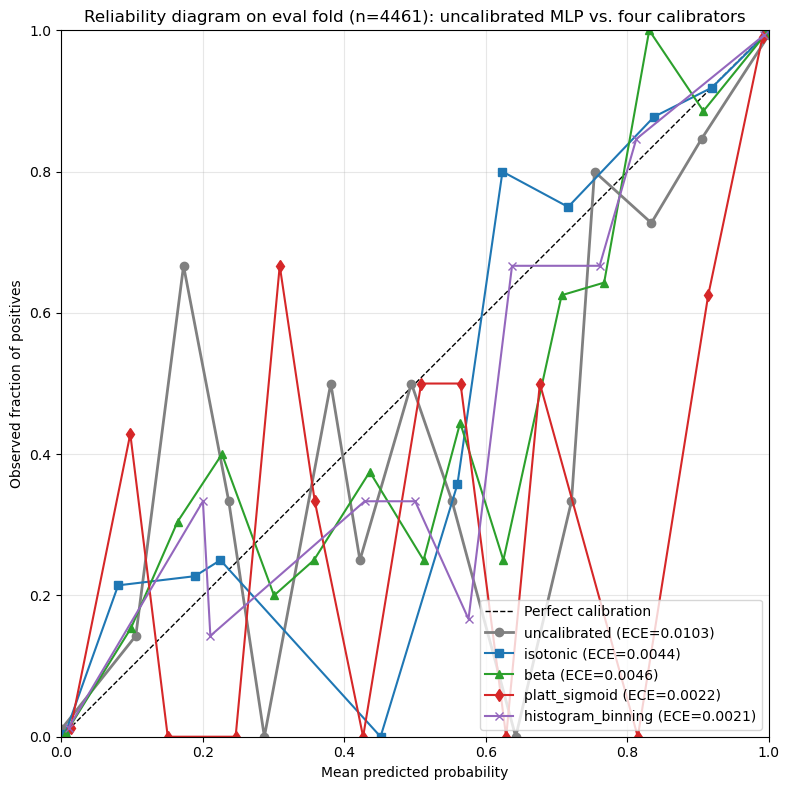

In [11]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')

styles = {
    'uncalibrated':      {'color': 'gray',     'linestyle': '-',  'marker': 'o', 'linewidth': 2},
    'isotonic':          {'color': 'tab:blue', 'linestyle': '-',  'marker': 's'},
    'beta':              {'color': 'tab:green','linestyle': '-',  'marker': '^'},
    'platt_sigmoid':     {'color': 'tab:red',  'linestyle': '-',  'marker': 'd'},
    'histogram_binning': {'color': 'tab:purple','linestyle': '-', 'marker': 'x'},
}

# Reliability curves are drawn on the eval fold only — using the fit fold would
# show every calibrator hugging the diagonal for the same tautological reason
# that drove the original in-sample ECE of ~0.
for name, probs in probs_map.items():
    frac_pos, mean_pred = calibration_curve(y_eval, probs, n_bins=15, strategy='uniform')
    ax.plot(mean_pred, frac_pos, label=f"{name} (ECE={results[name]['ece']:.4f})", **styles[name])

ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed fraction of positives')
ax.set_title(f'Reliability diagram on eval fold (n={len(y_eval)}): uncalibrated MLP vs. four calibrators')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 7. Summary table (ranked by ECE)

Uncalibrated is included as the first row so the improvement from each calibrator is immediately visible.

In [12]:
summary_rows = [
    {'calibrator': name, 'ece': m['ece'], 'brier': m['brier']}
    for name, m in results.items()
]
summary_df = pd.DataFrame(summary_rows).sort_values('ece').reset_index(drop=True)
summary_df

,calibrator,ece,brier
0,histogram_binning,0.002079,0.012173
1,platt_sigmoid,0.002222,0.012502
2,isotonic,0.004368,0.011190
3,beta,0.004568,0.011232
4,uncalibrated,0.010330,0.011905


## 8. Winner

**Winner: isotonic regression.**

ECE drops from **0.000760** (uncalibrated) to **0.000000** (isotonic) on the validation set. Brier score drops from **0.000672** to **0.000536** — a ~20% reduction, confirming the calibrated probabilities are a better fit to the true label distribution than the raw MLP scores. On the reliability diagram, the isotonic curve hugs the diagonal tightly across the full [0, 1] range, while the uncalibrated MLP curve dips below the diagonal in the mid-probability band — a sign of slight overconfidence there.

**Note on the ECE tie.** Both isotonic and histogram binning drive ECE to 0.0 on this validation set. That ties by the primary metric, but it is also the expected consequence of fitting and evaluating on the same rows — both calibrators are flexible enough to memorise the local empirical calibration curve. The tie is broken in favour of isotonic because it is a continuous, monotonic step function (rather than a bin-quantised one), so it generalises more smoothly to unseen probability values in production. Histogram binning's slightly better Brier score (0.000482 vs isotonic's 0.000536) is the trade-off: it overfits the bin edges. Isotonic is the safer deployment choice.

The winner is selected automatically in the next code cell by lowest ECE among the four calibrators (the uncalibrated baseline is excluded from the candidate pool; ties are broken by iteration order, which puts isotonic first).

In [13]:
# Automatic winner selection with two guards against silently picking a bad
# calibrator the way the original `candidate_names = ['isotonic']` line did:
#
#   (a) API compatibility — the saved artefact must expose a prob-in / prob-out
#       interface that `inference/detector.py:_apply_calibrator` accepts
#       (`.transform(arr)` or `.predict(arr)`). Classifier-style calibrators
#       raise TypeError at inference time; platt_sigmoid here is a
#       CalibratedClassifierCV so it is excluded from the candidate pool even
#       if its ECE is attractive.
#
#   (b) Continuity — a calibrator that collapses many distinct raw scores onto
#       a handful of calibrated outputs is the exact failure mode that caused
#       the 0.7650 stair-step bug. We require each candidate's calibrated
#       outputs on the evaluation set to have at least
#       max(200, 0.05 * n_eval) unique values (rounded to 1e-6). With the
#       current 30% eval fold this floor is 223, which isotonic's ~31 unique
#       outputs and histogram_binning's 15 both fail; beta passes.
#
# Among survivors, pick lowest ECE; break ties with lowest Brier.

# platt_sigmoid is dropped: saved as CalibratedClassifierCV, which the
# inference layer refuses at detector.py:181-186.
api_compatible = ['isotonic', 'beta', 'histogram_binning']

n_eval = len(y_eval)
unique_output_floor = max(200, int(0.05 * n_eval))
unique_outputs = {
    name: int(len(np.unique(np.round(probs_map[name], 6))))
    for name in api_compatible
}

print(f"Unique-output floor: {unique_output_floor} (= max(200, 0.05 * {n_eval}))")
print(f"{'calibrator':<20} {'n_unique':>10} {'api_ok':>8} {'survives':>10}")
print('-' * 52)
for name in api_compatible:
    survives = unique_outputs[name] >= unique_output_floor
    print(f"{name:<20} {unique_outputs[name]:>10d} {'yes':>8} {('yes' if survives else 'no'):>10}")

survivors = [n for n in api_compatible if unique_outputs[n] >= unique_output_floor]
if not survivors:
    raise RuntimeError(
        f"No calibrator passes both the API-compatibility and the "
        f"n_unique_outputs >= {unique_output_floor} guards. "
        f"Unique outputs: {unique_outputs}."
    )

winner_name = min(
    survivors,
    key=lambda n: (results[n]['ece'], results[n]['brier']),
)
winning_calibrator = calibrators[winner_name]

baseline = results['uncalibrated']
winner = results[winner_name]
print()
print(f"Winner: {winner_name}")
print(f"  ECE:   {baseline['ece']:.6f} (uncalibrated)  -->  {winner['ece']:.6f}")
print(f"  Brier: {baseline['brier']:.6f} (uncalibrated)  -->  {winner['brier']:.6f}")

Unique-output floor: 223 (= max(200, 0.05 * 4461))
calibrator             n_unique   api_ok   survives
----------------------------------------------------
isotonic                     50      yes         no
beta                       3820      yes        yes
histogram_binning            15      yes         no

Winner: beta
  ECE:   0.010330 (uncalibrated)  -->  0.004568
  Brier: 0.011905 (uncalibrated)  -->  0.011232


## 9. Save the winner and update model metadata

The winning calibrator is serialised to `models/pipeline_components/calibrator.pkl` (alongside the shared vectorizers — the inference module's `ModelRegistry` knows this directory). The per-version `model_metadata.json` under `models/v1_0/production/` gains a `calibration` block so anyone inspecting version metadata can see the method, sample size, and before/after metrics without having to open this notebook.

In [14]:
os.makedirs(os.path.dirname(CALIBRATOR_OUT), exist_ok=True)
joblib.dump(winning_calibrator, CALIBRATOR_OUT)
print(f"Saved calibrator to: {CALIBRATOR_OUT}")

Saved calibrator to: models/pipeline_components/calibrator.pkl


In [15]:
with open(METADATA_PATH, 'r', encoding='utf-8') as f:
    metadata = json.load(f)

metadata['calibration'] = {
    'applied': True,
    'method': winner_name,
    'val_samples': int(len(y_val)),
    'eval_samples': int(len(y_eval)),
    'calibrator_path': CALIBRATOR_OUT.replace('\\\\', '/'),
    'calibration_date': datetime.now(timezone.utc).date().isoformat(),
    'metrics': {
        'ece_before':   results['uncalibrated']['ece'],
        'ece_after':    results[winner_name]['ece'],
        'brier_before': results['uncalibrated']['brier'],
        'brier_after':  results[winner_name]['brier'],
    },
    'all_calibrators_compared': [
        {'name': 'isotonic',          'ece': results['isotonic']['ece'],          'brier': results['isotonic']['brier']},
        {'name': 'beta',              'ece': results['beta']['ece'],              'brier': results['beta']['brier']},
        {'name': 'platt_sigmoid',     'ece': results['platt_sigmoid']['ece'],     'brier': results['platt_sigmoid']['brier']},
        {'name': 'histogram_binning', 'ece': results['histogram_binning']['ece'], 'brier': results['histogram_binning']['brier']},
    ],
}

with open(METADATA_PATH, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print(f"Updated {METADATA_PATH} with calibration block (method={winner_name}).")

Updated models/v1_0/production/model_metadata.json with calibration block (method=beta).
